In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
df=pd.read_csv('/content/drive/MyDrive/dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5026 entries, 0 to 5025
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              5026 non-null   int64 
 1   workclass        5026 non-null   object
 2   fnlwgt           5026 non-null   int64 
 3   education        5026 non-null   object
 4   educational-num  5026 non-null   int64 
 5   marital-status   5026 non-null   object
 6   occupation       5026 non-null   object
 7   relationship     5026 non-null   object
 8   race             5026 non-null   object
 9   gender           5026 non-null   object
 10  capital-gain     5026 non-null   int64 
 11  capital-loss     5026 non-null   int64 
 12  hours-per-week   5026 non-null   int64 
 13  native-country   5026 non-null   object
 14  income           5026 non-null   object
dtypes: int64(6), object(9)
memory usage: 589.1+ KB


In [73]:
qc=df.columns[df.isin(['?']).any()]
qcount=df[qc].eq('?').sum()
qcount

workclass         316
occupation        316
native-country     77
dtype: int64

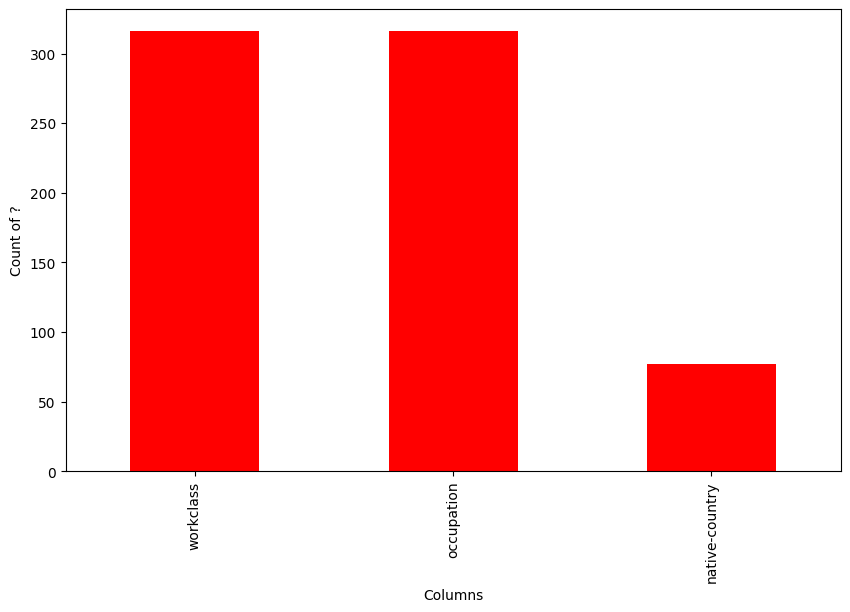

In [74]:
plt.figure(figsize=(10,6))
qcount.plot(kind='bar',color='red')
plt.xlabel('Columns')
plt.ylabel('Count of ?')
plt.show()

In [75]:
#replace the question marks with the immediate above value
df.replace('?', method='ffill',inplace=True)

In [76]:
rows, cols = (df=='?').any(axis=1), (df=='?').any()
print(df[rows][cols])
#Outputs an empty df since all '?' are replaced with the above values

Empty DataFrame
Columns: [age, workclass, fnlwgt, education, educational-num, marital-status, occupation, relationship, race, gender, capital-gain, capital-loss, hours-per-week, native-country, income]
Index: []


<ipython-input-76-bc36d36b6dbc>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[rows][cols])


In [77]:
a=[ch for ch in df['income']]
df['income'] = df['income'].apply(lambda x:0 if x==a[0] else 1)
df1=df.select_dtypes(include='number')
df1

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income
0,25,226802,7,0,0,40,0
1,38,89814,9,0,0,50,0
2,28,336951,12,0,0,40,1
3,44,160323,10,7688,0,40,1
4,18,103497,10,0,0,30,0
...,...,...,...,...,...,...,...
5021,55,129786,9,0,0,55,0
5022,29,245402,7,0,0,70,0
5023,24,192711,13,0,0,41,0
5024,41,240124,13,0,0,50,1


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#model 1
X = df1.drop('income', axis=1)
y = df1['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy1 = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print("Accuracy:", accuracy1)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_rep)


Accuracy: 0.8011928429423459

Confusion Matrix:
 [[736  25]
 [175  70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.88       761
           1       0.74      0.29      0.41       245

    accuracy                           0.80      1006
   macro avg       0.77      0.63      0.65      1006
weighted avg       0.79      0.80      0.77      1006



In [84]:
#Model 2
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print("Accuracy:", accuracy2)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.8449304174950298

Confusion Matrix:
 [[729  32]
 [124 121]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90       761
           1       0.79      0.49      0.61       245

    accuracy                           0.84      1006
   macro avg       0.82      0.73      0.76      1006
weighted avg       0.84      0.84      0.83      1006



Problem Statement : Predict the Income

```
`# This is formatted as code`
```



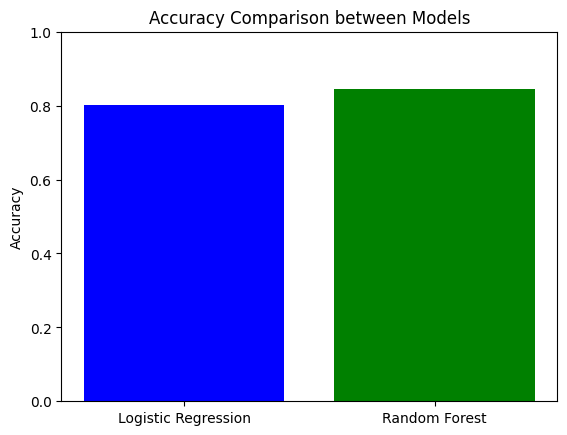

In [85]:
#Model two has a higher accuracy
models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy1, accuracy2]

plt.bar(models, accuracies, color=['blue', 'green'])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison between Models')
plt.ylim(0, 1)  # Set y-axis range to 0-1 for accuracy values
plt.show()